In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

# 1.0 Introduction
This report presents the findings of the Multi-Asset Performance & Risk team at a large Australian superannuation fund. The fund allocates capital across five asset-class sleeves — Australian Equities, International Equities, Fixed Income, Real Estate, and Private Equity/Venture Capital — each managed by an external manager and evaluated against a designated benchmark. Using monthly return data spanning the full sample period, this analysis delivers a comprehensive performance and attribution review consistent with institutional practice and APRA-aligned oversight principles. The report covers sleeve-level performance and risk metrics, total fund analysis relative to a composite benchmark constructed from Strategic Asset Allocation (SAA) weights, a set of APRA-inspired supervisory checks assessing the fund's long-run return adequacy, volatility profile, drawdown resilience, and stress scenario behaviour, and a Brinson-style attribution decomposing active return into allocation and selection effects across all five sleeves. Together, these findings provide the CIO with a clear diagnostic view of where value was created, where risk was taken, and whether the fund's behaviour remains consistent with its long-term investment mandate.

# 2.0 Data Overview & Loading
The dataset consists of monthly returns for five asset-class sleeves, including both manager returns and corresponding benchmarks, a risk-free rate proxy, and Strategic Asset Allocation (SAA) weights. All series are loaded via a centralised data pipeline that enforces a DatetimeIndex, validates monthly frequency, confirms manager-benchmark date alignment, and checks for missing values prior to analysis.

In [2]:
from src.data_loader import load_all_data

manager_data, benchmark_data, rf, saa = load_all_data()

# 3.0 Sleeve-Level Performance & Risk Metrics

In [3]:
from src.performance import build_performance_table

performance_table = build_performance_table(manager_data, benchmark_data, rf)
performance_table

,Ann. Return,Ann. Volatility,Sharpe Ratio,Tracking Error,Information Ratio,Max Drawdown
Asset Class,,,,,,
AUS EQ,0.0691,0.1416,0.2733,0.0440,0.2336,-0.2463
INTL EQ,0.1557,0.1196,1.0477,0.0257,0.6353,-0.1649
Bonds,0.0302,0.0446,-0.0048,0.0094,1.2077,-0.1135
Real Estate,0.1084,0.1872,0.4165,0.0710,0.3945,-0.2869
PE/VC,0.1024,0.1086,0.6632,0.0208,0.4120,-0.1162


In [4]:
from src.visuals import plot_sleeve_wealth_index, plot_sharpe_bar, plot_ir_bar

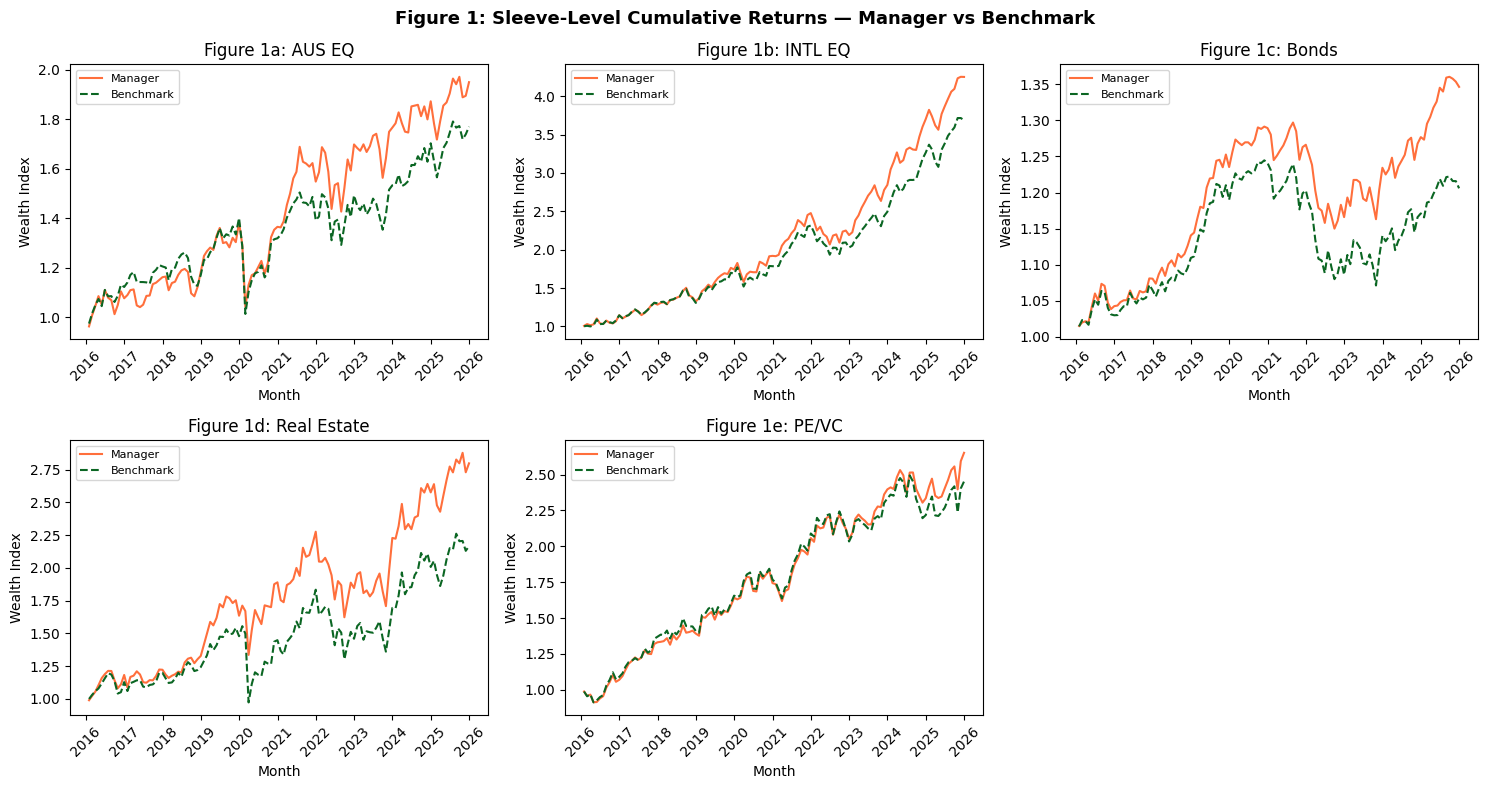

In [5]:
plot_sleeve_wealth_index(manager_data, benchmark_data)

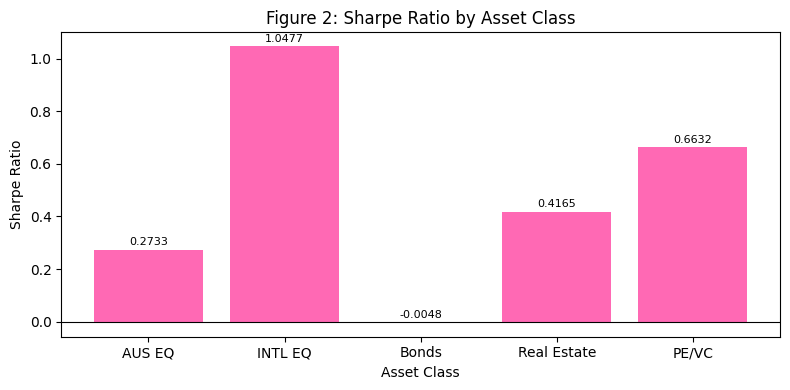

In [6]:
plot_sharpe_bar(performance_table)

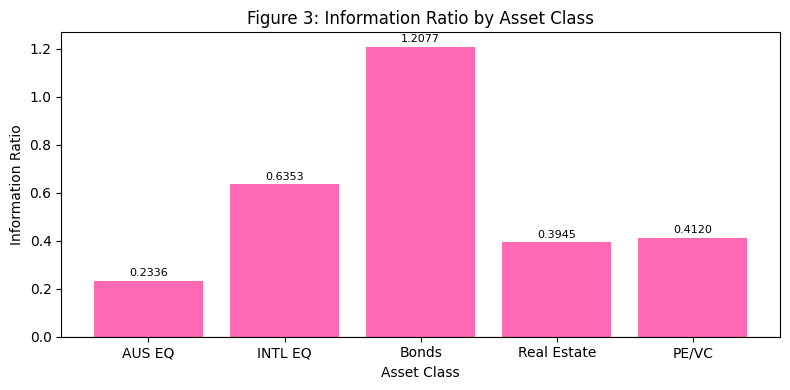

In [7]:
plot_ir_bar(performance_table)

Across the five sleeves, International Equities delivered the strongest risk-adjusted performance with an annualised Sharpe ratio of 1.0477 and a return of 15.57%, driven by strong absolute gains relative to its modest volatility of 11.96%. The Fixed Income sleeve produced the lowest absolute return (3.02%) and a near-zero Sharpe ratio of −0.0048, consistent with its defensive role during a period of rising rates. Real Estate exhibited the highest volatility (18.72%) and the deepest drawdown (−28.69%), reflecting its sensitivity to rate and liquidity conditions. PE/VC and INTL EQ both demonstrated strong information ratios (0.4120 and 0.6353 respectively), suggesting consistent manager outperformance relative to benchmark. Australian Equities lagged on both absolute and risk-adjusted terms, with a Sharpe of 0.2733 and an information ratio of 0.2336, indicating limited active value added over the sample period.

# 4.0 Total Fund Performance

In [8]:
from src.performance import compute_portfolio_returns, build_fund_table

In [9]:
portfolio_return, benchmark_return = compute_portfolio_returns(manager_data, benchmark_data)
fund_table = build_fund_table(portfolio_return, benchmark_return, rf)
fund_table

,Total Fund,Composite Benchmark
Metric,,
Annualised Return,0.1038,0.0824
Annualised Volatility,0.0685,0.0697
Sharpe Ratio,1.0704,0.7461
Max Drawdown,-0.0922,-0.1190


The total fund delivered an annualised return of 10.38%, comfortably exceeding the 6% target return, with a Sharpe ratio of 1.07 indicating strong risk-adjusted performance. Portfolio volatility of 6.85% sits within the defensive band, reflecting the diversification benefit of combining five asset classes under the TAA weighting scheme. The maximum drawdown of −9.22% remains well within the −25% supervisory threshold, demonstrating strong downside resilience over the sample period.

# 5.0 APRA-Inspired Performance & Risk Checks

In [10]:
from src.performance import run_apra_checks

In [11]:
apra_table = run_apra_checks(portfolio_return, rf)
apra_table

,Value,Threshold,Pass
Check,,,
1. Long-Run Return vs CPI + 4%,10.38%,≥ 6.00% (CPI 2% + 4%),Pass
2. Volatility Band (8–12%),6.85%,8.00% – 12.00%,Below band
3. Max Drawdown Threshold (> -25%),-9.22%,> -25.00%,Pass
4. Equity Shock Scenario (-20%),-14.60%,Observe impact,Negative under shock


The fund passes three of the four APRA-inspired checks. The long-run return of 10.38% comfortably exceeds the CPI + 4% target of 6.00%, confirming strong value creation over the sample period. The maximum drawdown of −9.22% remains well within the −25% supervisory threshold, demonstrating resilience during adverse market conditions. Volatility of 6.85% falls below the 8–12% balanced portfolio band, placing the fund in the defensive category — this reflects the diversification benefit of the multi-asset structure rather than a failure of risk management. Under a simulated equity shock of −20% applied simultaneously to the AUS EQ and INTL EQ sleeves, the fund returns a negative monthly outcome, highlighting meaningful sensitivity to equity market downturns given the combined 70% equity allocation under TAA weights. This underscores the importance of monitoring equity concentration risk within the fund's tactical positioning.

# 6.0 Performance Attribution

In [12]:
from src.attribution import compute_attribution
from src.visuals import plot_attribution

In [13]:
attribution_table = compute_attribution(manager_data, benchmark_data)
attribution_table

,Allocation Effect,Selection Effect,Total
AUS EQ,-0.0334,0.0420,0.0086
INTL EQ,0.0690,0.0442,0.1132
Bonds,-0.0099,0.0218,0.0119
Real Estate,0.0000,0.0099,0.0099
PE/VC,0.0482,0.0036,0.0519


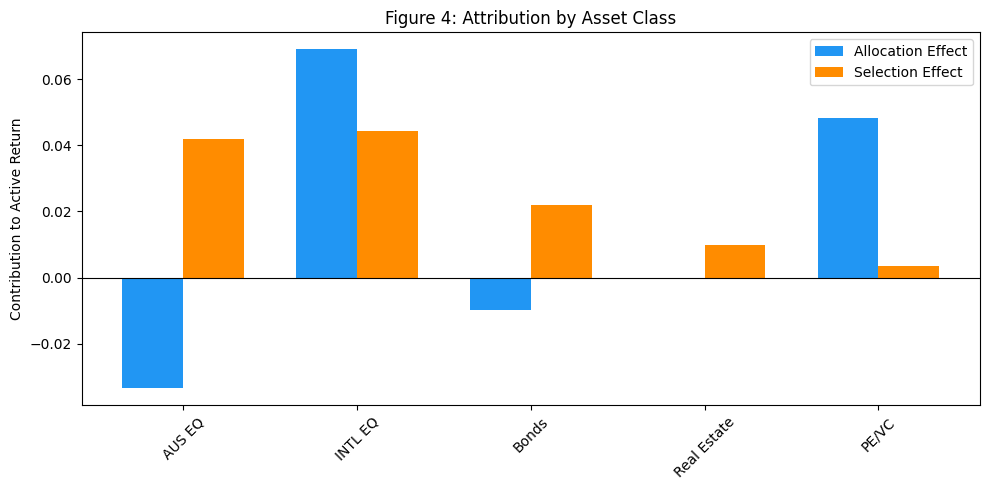

In [14]:
plot_attribution(attribution_table)

Attribution analysis reveals that International Equities were the primary driver of active outperformance, contributing positively through both allocation and selection effects — reflecting both the tactical decision to overweight the sleeve and strong manager performance within it. Australian Equities detracted through allocation (−0.0334) despite positive selection (0.0420), indicating that the underweight position relative to SAA cost the fund despite the manager outperforming its benchmark. The PE/VC sleeve contributed meaningfully through allocation (0.0482), driven by the TAA overweight from 5% to 10%, though selection added only marginally (0.0036). Bonds and Real Estate contributed positively through selection, suggesting manager skill within both sleeves, though their small weights limited the overall impact. In aggregate, allocation decisions were the dominant driver of active return, with selection providing a consistent but smaller positive contribution across most sleeves.

# 7.0 Key Insights
This analysis delivers five key findings for the CIO. First, International Equities were the standout performer across the fund, generating an annualised return of 15.57% and a Sharpe ratio of 1.05, and contributing the largest active return through both positive allocation and selection effects. Second, the total fund achieved an annualised return of 10.38% with a Sharpe ratio of 1.07, comfortably exceeding the 6% target return while maintaining a maximum drawdown of just −9.22%. Third, the TAA decision to overweight INTL EQ and PE/VC relative to SAA weights was the primary driver of active outperformance, with allocation effects dominating selection across most sleeves. Fourth, Australian Equities remain the weakest sleeve — despite positive manager selection, the underweight TAA position detracted from overall active return, warranting a review of the tactical positioning. Finally, the fund's volatility of 6.85% sits in the defensive band rather than the balanced band, suggesting the current asset mix may be more conservative than intended under the SAA design — this warrants consideration in future rebalancing decisions.

# 8.0 Limitations
Several limitations should be considered when interpreting these results. First, both TAA and SAA weights are assumed constant throughout the sample period — in practice, weights would be rebalanced periodically, and the fixed-weight assumption may overstate or understate actual active returns. Second, transaction costs, management fees, and taxes are excluded from all return calculations, meaning reported performance figures represent gross returns that would be lower on a net basis. Third, the risk-free rate proxy is a simplified monthly series and may not accurately reflect the actual short-term rate environment across the full sample period, introducing potential noise into Sharpe and Information Ratio calculations. Fourth, the Brinson attribution model used here is a simplified two-factor decomposition that omits the interaction effect — in practice, a three-factor model would more precisely attribute the joint impact of allocation and selection decisions. Fifth, the PE/VC benchmark is a stylised synthetic series that may not accurately reflect the illiquidity premium or valuation smoothing inherent in private market investments, potentially understating true risk for that sleeve. Finally, the APRA-inspired checks applied here are simplified educational proxies and do not constitute actual regulatory compliance assessment.

# 9.0 Conclusion
This report demonstrates that the multi-asset fund delivered strong risk-adjusted performance over the sample period, generating an annualised return of 10.38% and a Sharpe ratio of 1.07, both materially exceeding the composite benchmark. The TAA decision to overweight International Equities and PE/VC relative to SAA weights was the primary driver of active outperformance, while manager selection added further value across most sleeves. The fund's conservative volatility profile and strong drawdown resilience are consistent with the risk management expectations of a large Australian superannuation fund. These findings confirm the fund is well-positioned relative to its long-term investment mandate, though continued monitoring of equity concentration risk and rebalancing frequency is recommended.